GRAPH ANALYTICS AND CENTRALITY REPORT

Graph: City-City similarity graph

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import re
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def canonical_city(city):
    if pd.isna(city): return city
    city = str(city).strip().lower()
    city = re.sub(r'[^a-z0-9\s]', '', city)
    city = re.sub(r'\s+', ' ', city)
    return city

In [ ]:
city_feat_pca  = pd.read_parquet('/content/drive/MyDrive/yelp_dataset/data/processed/personality/city_features_pca_new.parquet')
city_features  = pd.read_parquet('/content/drive/MyDrive/yelp_dataset/data/processed/city_features_new.parquet')


In [ ]:
# w11 data
SAVE_PATH = '/content/drive/MyDrive/yelp_dataset/data/processed/w11/'
# Tablas principales
city_popularity    = pd.read_parquet(SAVE_PATH + 'w10_city_popularity.parquet')
cities_filtered    = pd.read_parquet(SAVE_PATH + 'w10_cities_filtered.parquet')
user_city_f        = pd.read_parquet(SAVE_PATH + 'w10_user_city_f.parquet')
train_uc           = pd.read_parquet(SAVE_PATH + 'w10_train_uc.parquet')
test_uc            = pd.read_parquet(SAVE_PATH + 'w10_test_uc.parquet')

# SVD factors
user_factors  = np.load(SAVE_PATH + 'w10_user_factors.npy')
item_factors  = np.load(SAVE_PATH + 'w10_item_factors.npy')

# Índices
_u = pd.read_parquet(SAVE_PATH + 'w10_user_to_idx.parquet')
user_to_idx   = dict(zip(_u['user_id'], _u['idx']))

_c = pd.read_parquet(SAVE_PATH + 'w10_city_to_idx_cf.parquet')
city_to_idx_cf = dict(zip(_c['city_clean'], _c['idx']))

# Content embeddings
X_content          = np.load(SAVE_PATH + 'w10_X_content.npy')
_cl = pd.read_parquet(SAVE_PATH + 'w10_content_city_list.parquet')
content_city_list  = _cl['city_clean'].tolist()
content_city_to_idx = {c: i for i, c in enumerate(content_city_list)}

# CF bounds
_b     = pd.read_parquet(SAVE_PATH + 'w10_cf_bounds.parquet')
cf_min = _b['cf_min'].iloc[0]
cf_max = _b['cf_max'].iloc[0]

# Reconstruir mapas desde cities_filtered
pc_columns       = [c for c in cities_filtered.columns if c.startswith('PC')]
city_cluster_map = dict(zip(cities_filtered['city_clean'], cities_filtered['cluster']))
city_list        = cities_filtered['city_clean'].tolist()

# Popularity dict
baseline_scores = dict(zip(city_popularity['city_clean'],
                           city_popularity['baseline_score']))
pop_dict = dict(zip(
    city_popularity['city_clean'],
    0.7 * (city_popularity['train_users'] / city_popularity['train_users'].max()) +
    0.3 * (city_popularity['train_avg_rating'] / city_popularity['train_avg_rating'].max())
))

# Reconstruir cf_score function
def cf_score(user_id, city):
    if user_id not in user_to_idx: return 0.0
    if city not in city_to_idx_cf: return 0.0
    return np.dot(user_factors[user_to_idx[user_id]],
                  item_factors[city_to_idx_cf[city]])

print(f'  Cities:       {len(city_list)}')
print(f'  Train users:  {train_uc["user_id"].nunique():,}')
print(f'  CF matrix:    {user_factors.shape} × {item_factors.shape}')
print(f'  cf_min={cf_min:.3f}  cf_max={cf_max:.3f}')

  Cities:       214
  Train users:  7,991
  CF matrix:    (7991, 40) × (213, 40)
  cf_min=-1.202  cf_max=5.610


In [ ]:
cities_filtered['cluster'].value_counts()

,count
cluster,
3,151
1,55
0,6
2,2


In [ ]:
print('cluster' in cities_filtered.columns)  # debe ser True
print(cities_filtered['cluster'].value_counts())

print(f'Cities for graph: {len(cities_filtered)}')
print(f'PC dimensions:    {len(pc_columns)}')

True
cluster
3    151
1     55
0      6
2      2
Name: count, dtype: int64
Cities for graph: 214
PC dimensions:    28


#Graph definition

**Why Cities are the Nodes?**

The recommendation system operates at the city level rather than the business level. Users are recommended destinations, not individual businesses. Therefore, cities constitute the natural graph entities. The graph captures structural relationships between city personalities derived from aggregated business characteristics.

**Why Edges Represent Similarity?**

An edge is created when two cities exhibit sufficiently similar commercial personalities in the PCA embedding space. Rather than connecting cities based on geography or administrative boundaries, edges represent similarity in business composition, dining patterns, service availability, customer engagement, and other aggregated characteristics. This allows the graph to capture latent relationships between destinations that may be geographically distant but commercially similar.

**Why Cosine Similarity is Used as the Edge Weight?**

Edge weights are defined using cosine similarity between PCA city embeddings. Cosine similarity measures how closely two cities align in terms of their personality profile while being less sensitive to differences in magnitude. A higher weight indicates that two cities share highly similar commercial structures, whereas lower weights correspond to more distinct destination profiles. This makes cosine similarity particularly suitable for comparing cities represented by high-dimensional feature vectors.

**Why the Graph is Undirected?**

The graph is modeled as undirected because similarity is inherently symmetric. If City A is similar to City B, then City B is equally similar to City A. Consequently, no directionality exists in the relationship, and each edge represents a mutual similarity connection between two destinations.

**Why This Graph Definition Supports the Domain?**

The objective of the project is to recommend destinations using a hybrid model that combines collaborative filtering, popularity, and content-based signals. The city-to-city graph is not used directly for recommendation; instead, it provides a structural view of the destination space by connecting cities with similar commercial personalities. This network enables graph analytics to identify representative cities, bridge destinations, and hidden gems that complement the insights obtained from the recommendation model.

**Note on the City Catalog (carried over from Week 10):**

The set of cities used as nodes is the same filtered catalog defined in Week 10, restricted to cities with between 70 and 1,043 businesses. This range was chosen to exclude cities with too few businesses to produce a reliable personality profile, as well as a small number of dominant mega-cities (e.g., very high business-count cities) whose scale would otherwise distort the PCA embedding space and bias similarity comparisons. The graph in this report is therefore built on the same node population already justified and validated in the Week 10 recommendation pipeline, ensuring consistency between the recommendation system and the graph analytics layer.


In [ ]:
X = cities_filtered[pc_columns].values
city_list = cities_filtered['city_clean'].tolist()

# Matriz de similitud (n_cities × n_cities)
sim_matrix = cosine_similarity(X)
print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'Mean similarity: {sim_matrix.mean():.3f}')
print(f'Max similarity (excl diagonal): {np.fill_diagonal(sim_matrix.copy(), 0) or sim_matrix.max():.3f}')

Similarity matrix shape: (214, 214)
Mean similarity: 0.315
Max similarity (excl diagonal): 1.000


In [ ]:
# ── Análisis de densidad para elegir THRESHOLD ────────────────────
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.92, 0.95, 0.97]
print("Threshold analysis:")
print(f"{'Threshold':>10} {'Edges':>10} {'Density':>10} {'Avg Degree':>12}")
for t in thresholds:
    mask_t = (sim_matrix >= t)
    np.fill_diagonal(mask_t, False)
    edges = mask_t.sum() // 2
    n = len(city_list)
    density = edges / (n * (n-1) / 2)
    avg_deg = mask_t.sum(axis=1).mean()
    print(f"{t:>10.2f} {edges:>10,} {density:>10.4f} {avg_deg:>12.2f}")

Threshold analysis:
 Threshold      Edges    Density   Avg Degree
      0.70      1,197     0.0525        11.19
      0.75        604     0.0265         5.64
      0.80        256     0.0112         2.39
      0.85         78     0.0034         0.73
      0.90         14     0.0006         0.13
      0.92          8     0.0004         0.07
      0.95          3     0.0001         0.03
      0.97          0     0.0000         0.00


In [ ]:
print(
    f"{'Threshold':<10}"
    f"{'Edges':<10}"
    f"{'Density':<12}"
    f"{'AvgDeg':<10}"
    f"{'Components':<12}"
    f"{'LargestCC':<12}"
    f"{'Isolated':<10}"
)

for t in [0.70, 0.75, 0.80]:

    G_t = nx.Graph()
    G_t.add_nodes_from(city_list)

    for i in range(len(city_list)):
        for j in range(i + 1, len(city_list)):
            if sim_matrix[i, j] >= t:
                G_t.add_edge(city_list[i], city_list[j],
                             weight=float(sim_matrix[i, j]))

    edges = G_t.number_of_edges()
    density = nx.density(G_t)
    avg_deg = np.mean([d for _, d in G_t.degree()])

    components = list(nx.connected_components(G_t))
    n_components = len(components)
    largest_cc = max(len(c) for c in components)
    isolated = len(list(nx.isolates(G_t)))

    print(
        f"{t:<10.2f}"
        f"{edges:<10}"
        f"{density:<12.4f}"
        f"{avg_deg:<10.2f}"
        f"{n_components:<12}"
        f"{largest_cc:<12}"
        f"{isolated:<10}"
    )

Threshold Edges     Density     AvgDeg    Components  LargestCC   Isolated  
0.70      1197      0.0525      11.19     9           204         6         
0.75      604       0.0265      5.64      23          190         20        
0.80      256       0.0112      2.39      73          120         62        


**Threshold selection:**

Threshold 0.75 was selected because it provides the best balance between connectivity and structural discrimination. At this threshold, the graph remains sparse (average degree ≈ 5.6) while preserving a large giant component (190 cities, 88.8% of the network). Lower thresholds produce overly dense networks that reduce the interpretability of centrality measures, whereas higher thresholds fragment the graph into many small components and isolated cities. Therefore, 0.75 retains meaningful similarity relationships while revealing the underlying structure of destination personalities.

#Graph construction

In [ ]:
THRESHOLD = 0.75 # after threshold analysis

G = nx.Graph()

# Agregar nodos con atributos
city_features['city_clean'] = city_features['city'].apply(canonical_city)
city_feat_pca['city_clean'] = city_feat_pca['city'].apply(canonical_city)

# Ensure unique city_clean entries before setting index to avoid TypeErrors
cities_orig_lookup = city_features.drop_duplicates(subset=['city_clean']).set_index('city_clean')

for i, city in enumerate(city_list):
    cluster_id = city_cluster_map.get(city, -1)

    if city in cities_orig_lookup.index:
        row = cities_orig_lookup.loc[city]
        n_biz  = float(row['n_businesses']) if 'n_businesses' in row else 0.0
        avg_s  = float(row['avg_stars'])    if 'avg_stars'    in row else 0.0
    else:
        n_biz, avg_s = 0.0, 0.0

    G.add_node(city,
        cluster=int(cluster_id) if not pd.isna(cluster_id) else -1,
        n_businesses=n_biz,
        avg_stars=avg_s
    )

# Add edges
for i in range(len(city_list)):
    for j in range(i+1, len(city_list)):
        w = sim_matrix[i, j]
        if w >= THRESHOLD:
            G.add_edge(city_list[i], city_list[j], weight=float(w))

print(f'Graph constructed:')
print(f'  Nodes:   {G.number_of_nodes():,}')
print(f'  Edges:   {G.number_of_edges():,}')
print(f'  Density: {nx.density(G):.4f}')
print(f'  Is connected: {nx.is_connected(G)}')

Graph constructed:
  Nodes:   214
  Edges:   604
  Density: 0.0265
  Is connected: False


The graph is constructed from cosine similarity between PCA embeddings. Cluster labels obtained from K-Means are stored as node attributes and are used only for visualization and interpretation of the resulting network structure.

#Graph report

##Connected components

In [ ]:
# ── Connected components ─────────────────────────────────────────
components  = list(nx.connected_components(G))
comp_sizes  = sorted([len(c) for c in components], reverse=True)

print(f'Connected components: {len(components)}')
print(f'Largest component:    {comp_sizes[0]} nodes')
print(f'Isolated nodes:       {sum(1 for c in comp_sizes if c == 1)}')
print(f'Top 10 sizes:         {comp_sizes[:10]}')

Connected components: 23
Largest component:    190 nodes
Isolated nodes:       20
Top 10 sizes:         [190, 2, 2, 1, 1, 1, 1, 1, 1, 1]


The graph is dominated by a single giant connected component containing most cities in the catalog. This indicates that city personalities form a largely continuous space rather than isolated groups. Most cities share meaningful similarities with at least a few others.

The remaining small components and isolated nodes correspond to highly distinctive cities whose commercial profiles differ substantially from the rest of the catalog. These cities may represent niche destinations or unusual business ecosystems.

In [ ]:
# ── Detalle de ciudades aisladas y componentes pequeños ───────────
isolated_cities = [c for c in components if len(c) == 1]
small_components = [c for c in components if 1 < len(c) <= 5]

print(f'Isolated cities (component size = 1): {len(isolated_cities)}')
if isolated_cities:
    print('  ->', ', '.join(sorted([list(c)[0] for c in isolated_cities])))

print(f'\nSmall components (size 2-5): {len(small_components)}')
for comp in small_components:
    print('  ->', sorted(list(comp)))


Isolated cities (component size = 1): 20
  -> apollo beach, audubon, bala cynwyd, blue bell, bordentown, chadds ford, garden city, horsham, hudson, limerick, marana, montecito, old hickory, perkasie, port richey, richboro, saint charles, tampa bay, valley park, west chester

Small components (size 2-5): 2
  -> ['berwyn', 'malvern']
  -> ['sherwood park', 'st albert']


These isolated cities and small components represent destinations whose commercial personality, as captured by the PCA embedding, does not reach the similarity threshold (0.75) with any other city in the catalog — or only with one or two others. In practice, this means their business composition (mix of categories, price levels, review patterns, etc.) is distinctive enough that they do not resemble the rest of the destinations strongly enough to form part of the main network. They are not errors or noise; they are legitimate niche destinations that the graph correctly separates from the main personality cluster.


## Degree and weighted degree

In [ ]:
degrees     = dict(G.degree())
deg_series  = pd.Series(degrees)

weighted_deg = {
    node: sum(d['weight'] for _, _, d in G.edges(node, data=True))
    for node in G.nodes()
}
wd_series = pd.Series(weighted_deg)

print('Degree statistics:')
print(deg_series.describe().round(2))

print('\nTop 15 by degree:')
for city, deg in deg_series.nlargest(15).items():
    cl = G.nodes[city].get('cluster', '?')
    print(f'  {city:<35} degree={deg:3d}  cluster={cl}')

print('\nTop 15 by weighted degree (strength):')
for city, wd in wd_series.nlargest(15).items():
    cl = G.nodes[city].get('cluster', '?')
    print(f'  {city:<35} strength={wd:.3f}  cluster={cl}')

Degree statistics:
count    214.00
mean       5.64
std        5.12
min        0.00
25%        2.00
50%        5.00
75%        8.00
max       30.00
dtype: float64

Top 15 by degree:
  levittown                           degree= 30  cluster=3
  florissant                          degree= 25  cluster=3
  brandon                             degree= 23  cluster=3
  smyrna                              degree= 21  cluster=3
  arnold                              degree= 19  cluster=3
  mooresville                         degree= 19  cluster=3
  greenwood                           degree= 18  cluster=3
  new castle                          degree= 18  cluster=3
  marrero                             degree= 16  cluster=3
  sicklerville                        degree= 16  cluster=3
  warminster                          degree= 16  cluster=3
  cherry hill                         degree= 15  cluster=3
  hendersonville                      degree= 15  cluster=3
  hermitage                           d

## Centrality Computation Scope

Centrality measures are computed only on the largest connected component. Metrics such as PageRank, closeness, and betweenness rely on network connectivity and shortest paths. Restricting the analysis to the giant component avoids distortions caused by isolated cities and disconnected subgraphs.

In [ ]:
# Centrality — trabajar sobre el componente más grande ──────────
largest_cc = max(nx.connected_components(G), key=len)
G_main     = G.subgraph(largest_cc).copy()
print(f'Largest component: {G_main.number_of_nodes()} nodes, {G_main.number_of_edges()} edges')
for u, v, d in G_main.edges(data=True):
    d['distance'] = 1.0 - d['weight']

betweenness = nx.betweenness_centrality(G_main, weight='distance', normalized=True)
closeness   = nx.closeness_centrality(G_main, distance='distance')
pagerank    = nx.pagerank(G_main, weight='weight', alpha=0.85)

try:
    eigenvector = nx.eigenvector_centrality(G_main, weight='weight', max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {n: 0.0 for n in G_main.nodes()}
    print('Eigenvector centrality did not converge — set to 0')

centrality_df = pd.DataFrame({
    'city':        list(G_main.nodes()),
    'degree':      [degrees.get(n, 0)     for n in G_main.nodes()],
    'strength':    [weighted_deg.get(n,0) for n in G_main.nodes()],
    'betweenness': [betweenness.get(n, 0) for n in G_main.nodes()],
    'closeness':   [closeness.get(n, 0)   for n in G_main.nodes()],
    'pagerank':    [pagerank.get(n, 0)    for n in G_main.nodes()],
    'eigenvector': [eigenvector.get(n, 0) for n in G_main.nodes()],
    'cluster':     [G_main.nodes[n].get('cluster', -1) for n in G_main.nodes()],
    'n_businesses':[G_main.nodes[n].get('n_businesses', 0) for n in G_main.nodes()],
}).sort_values('pagerank', ascending=False).reset_index(drop=True)

print('\nTop 15 by PageRank:')
print(centrality_df[['city','pagerank','degree','betweenness','cluster']].head(15).to_string(index=False))

Largest component: 190 nodes, 602 edges

Top 15 by PageRank:
        city  pagerank  degree  betweenness  cluster
   levittown  0.018846      30     0.211021        3
     brandon  0.015775      23     0.217944        3
  florissant  0.014794      25     0.085219        3
      smyrna  0.012539      21     0.084656        3
   greenwood  0.012101      18     0.092086        3
     marlton  0.011752      15     0.065631        3
 cherry hill  0.011579      15     0.036474        3
 mooresville  0.011340      19     0.028763        3
      arnold  0.011159      19     0.026230        3
  warminster  0.011155      16     0.095745        3
  new castle  0.010508      18     0.003434        3
 springfield  0.010144      14     0.070359        3
sicklerville  0.009798      16     0.052685        3
        lutz  0.009631      12     0.032815        3
     ardmore  0.009625       8     0.039739        1


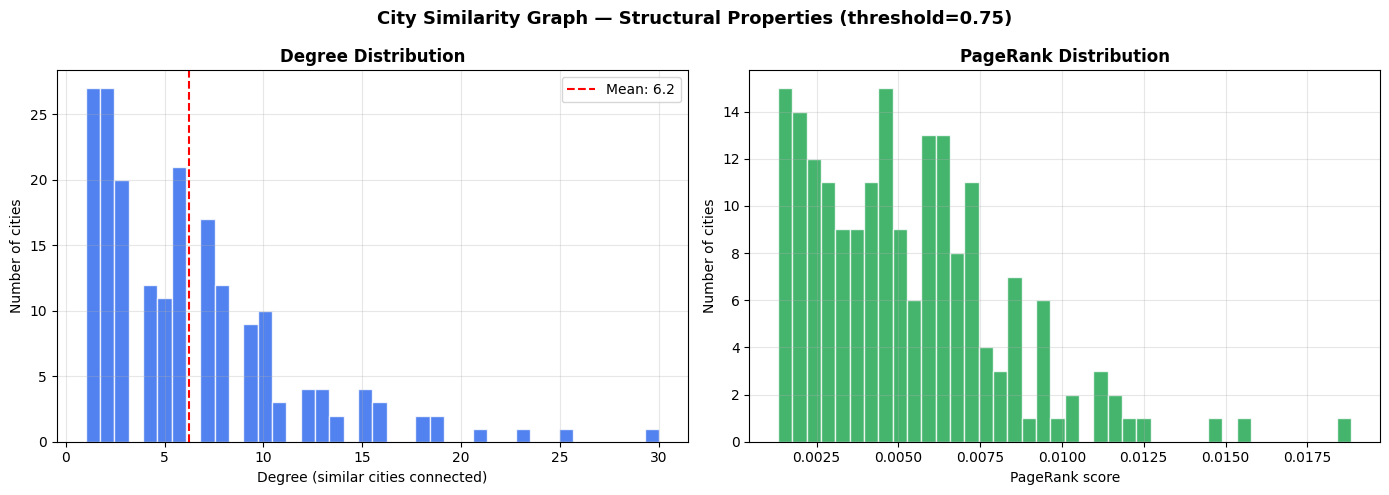

In [ ]:
# ── PLOT 1: Degree distribution + PageRank distribution ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

deg_vals = [d for d in degrees.values() if d > 0]
axes[0].hist(deg_vals, bins=40, color='#2563EB', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(deg_vals), color='red', linestyle='--',
                label=f'Mean: {np.mean(deg_vals):.1f}')
axes[0].set_xlabel('Degree (similar cities connected)')
axes[0].set_ylabel('Number of cities')
axes[0].set_title('Degree Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

pr_vals = list(pagerank.values())
axes[1].hist(pr_vals, bins=40, color='#16A34A', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('PageRank score')
axes[1].set_ylabel('Number of cities')
axes[1].set_title('PageRank Distribution', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle(f'City Similarity Graph — Structural Properties (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Degree Distribution Analysis:**

The degree distribution is highly heterogeneous. Most cities have relatively few connections, while a small number of cities exhibit very high degree values. This suggests the existence of representative city archetypes that share similarities with many other destinations. Peripheral cities are more specialized and occupy unique positions within the city personality space.

**PageRank Analysis:**

PageRank identifies cities that are not only highly connected but also connected to other influential cities. These locations can be interpreted as central reference points within the city personality network. They represent common commercial patterns that characterize large regions of the catalog and may serve as useful anchors for recommendation and exploration.

/tmp/ipykernel_15809/272271626.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = cm.get_cmap('tab10', len(cluster_ids))


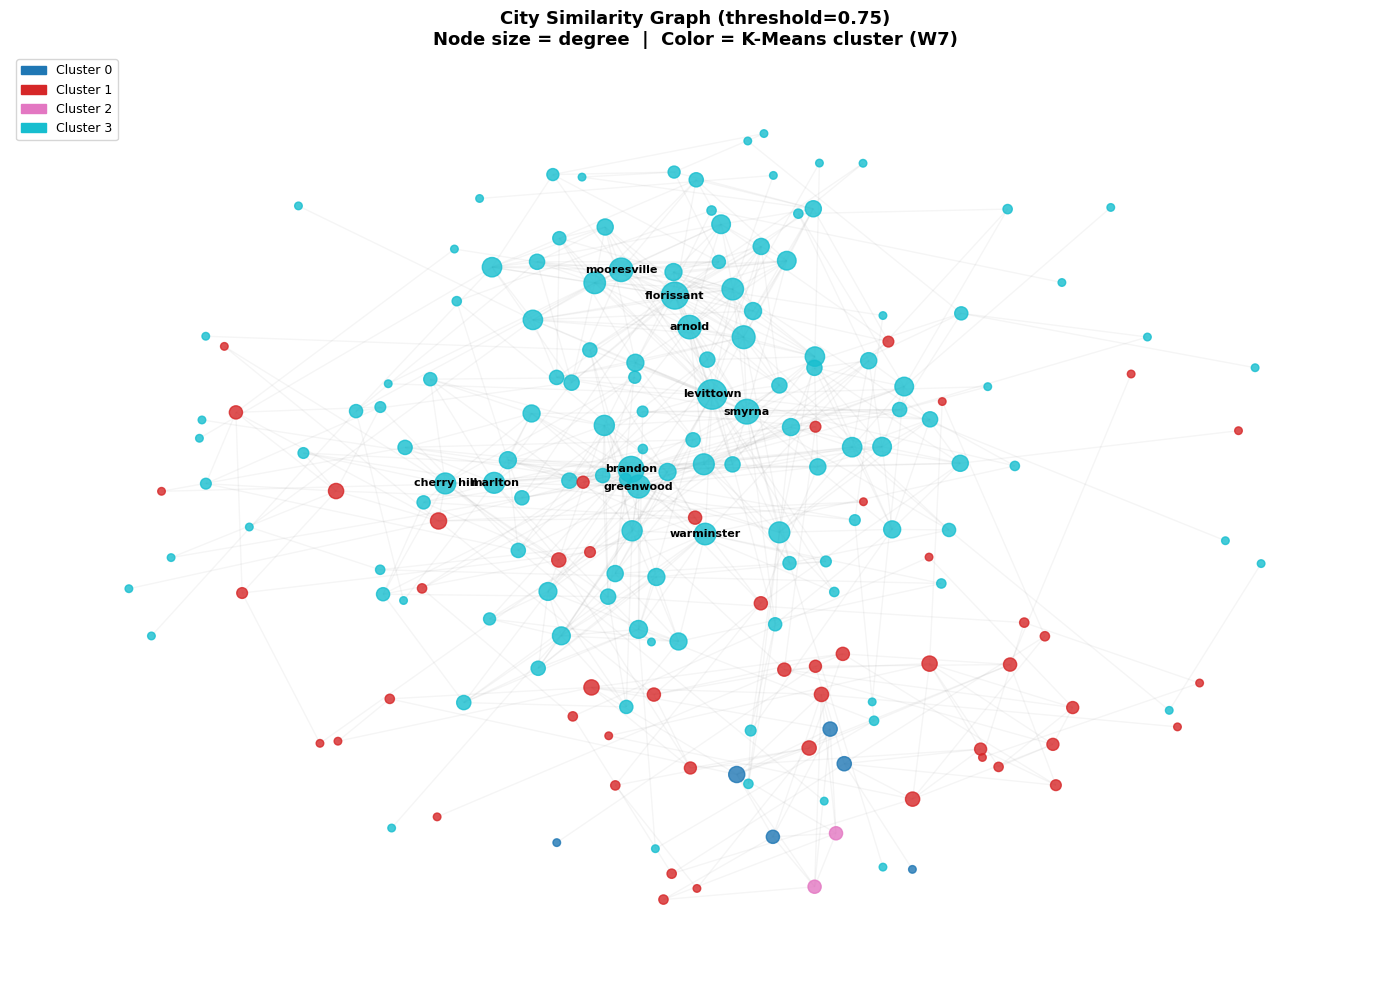

In [ ]:
# ── PLOT 2: Graph colored by cluster ─────────────────────────────
cluster_ids = sorted(set(nx.get_node_attributes(G_main, 'cluster').values()))
cmap        = cm.get_cmap('tab10', len(cluster_ids))
color_map   = {c: cmap(i) for i, c in enumerate(cluster_ids)}

node_colors = [color_map.get(G_main.nodes[n].get('cluster', -1), 'gray')
               for n in G_main.nodes()]
node_sizes  = [max(30, G_main.degree(n) * 15) for n in G_main.nodes()]

pos = nx.spring_layout(G_main, seed=42, k=0.4)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_main, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G_main, pos, alpha=0.08,
                       edge_color='gray', ax=ax)

# Anotar top 10 por PageRank
top10 = centrality_df.nlargest(10, 'pagerank')['city'].tolist()
labels = {n: n for n in G_main.nodes() if n in top10}
nx.draw_networkx_labels(G_main, pos, labels,
                        font_size=8, font_weight='bold', ax=ax)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[c], label=f'Cluster {c}')
                  for c in cluster_ids if c != -1]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title(f'City Similarity Graph (threshold={THRESHOLD})\n'
             f'Node size = degree  |  Color = K-Means cluster (W7)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('city_graph.png', dpi=150, bbox_inches='tight')
plt.show()

The graph reveals a strongly connected city personality network dominated by Cluster 3. Most highly connected and central cities belong to this cluster, suggesting that it represents the most common commercial archetype in the Yelp ecosystem. Cities such as Levittown, Brandon, Florissant, Smyrna, and Greenwood occupy central positions and act as reference points for many other destinations.

The network is not fragmented into completely isolated communities. Instead, multiple connections exist between clusters, indicating that city personalities evolve gradually rather than forming strictly separated categories. This supports the idea that urban-commercial profiles exist on a continuum of lifestyle characteristics.

Node size highlights degree centrality. Larger nodes correspond to cities whose commercial personalities are shared by many other cities. Smaller peripheral nodes represent more specialized destinations with fewer close analogues in the catalog.

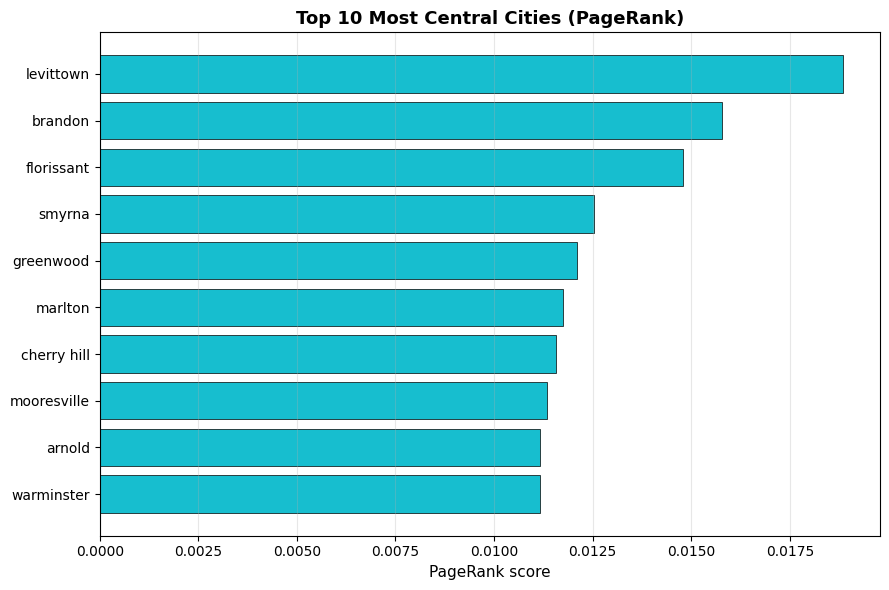

In [ ]:
# ── PLOT EXTRA: Top 10 cities by PageRank (simple bar chart) ──────
top10_pr = centrality_df.nlargest(10, 'pagerank')[['city', 'pagerank', 'cluster']].copy()
top10_pr = top10_pr.sort_values('pagerank')

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [color_map.get(c, 'gray') for c in top10_pr['cluster']]
ax.barh(top10_pr['city'], top10_pr['pagerank'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('PageRank score', fontsize=11)
ax.set_title('Top 10 Most Central Cities (PageRank)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top10_pagerank.png', dpi=150, bbox_inches='tight')
plt.show()


This simplified view isolates the ten most structurally central cities in the personality network, independent of the full graph layout. These cities are the clearest reference points (archetypes) of the catalog: their commercial profile is shared by many other destinations, which is why they rank highest in PageRank. This chart is meant as a quick, presentation-friendly summary of the same result shown in the full network plot above.


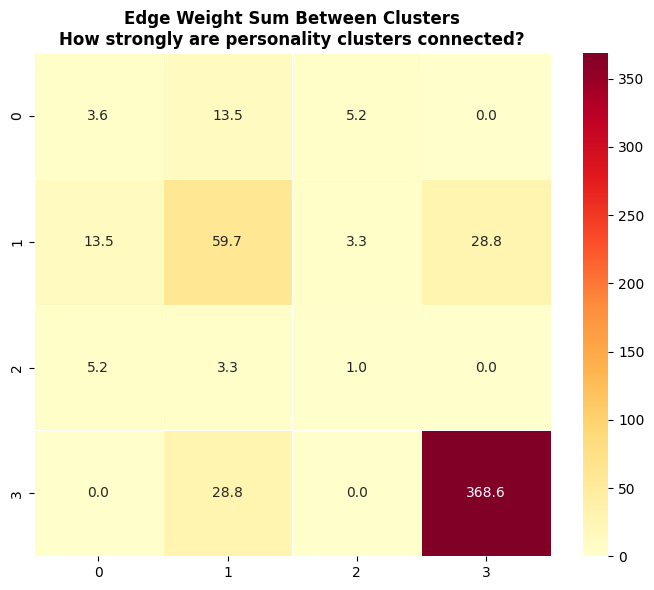

In [ ]:
# ── PLOT 3: Cluster connectivity heatmap ───────────────────
import seaborn as sns

# Ensure all clusters are included, not just those in G_main
all_clusters_in_data = sorted([c for c in cities_filtered['cluster'].unique() if c != -1])
inter_cluster  = pd.DataFrame(0.0, index=all_clusters_in_data, columns=all_clusters_in_data)

for u, v, d in G.edges(data=True):
    cu = G.nodes[u].get('cluster', -1)
    cv = G.nodes[v].get('cluster', -1)
    if cu == -1 or cv == -1:
        continue
    inter_cluster.loc[cu, cv] += d['weight']
    if cu != cv:
        inter_cluster.loc[cv, cu] += d['weight']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(inter_cluster, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Edge Weight Sum Between Clusters\n'
             'How strongly are personality clusters connected?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_connectivity.png', dpi=150, bbox_inches='tight')
plt.show()

The cluster connectivity heatmap shows that Cluster 3 is by far the most internally connected group, with a total internal edge weight of 368.6. This indicates that cities in this cluster share highly similar commercial personalities and form the structural core of the network.

Cluster 1 exhibits moderate internal cohesion (59.7) and maintains meaningful connections with Cluster 3 (28.8), suggesting partial overlap between these city archetypes.

Clusters 0 and 2 display substantially lower connectivity, indicating that they represent more distinctive and specialized commercial environments. Their weaker links to other clusters suggest that they occupy peripheral positions in the city personality space.

Overall, the graph structure is dominated by a mainstream commercial archetype (Cluster 3), while the remaining clusters capture more niche destination profiles.

# Comparison

The comparison is not intended as a validation. Instead, it evaluates whether structurally central cities in the personality graph are also prioritized by the recommendation model.

In [ ]:
# ── Popularity ranking ────────────────────────────────────────────
pop_rank_df = city_popularity.sort_values('baseline_score', ascending=False).reset_index(drop=True)
pop_rank_df['popularity_rank'] = range(1, len(pop_rank_df)+1)
pop_rank_dict = dict(zip(pop_rank_df['city_clean'], pop_rank_df['popularity_rank']))

# ── Hybrid ranking — promedio sobre muestra de usuarios ───────────
print('Computing hybrid scores per city over sample of users...')

# Reconstruir lo necesario para recommend_hybrid
train_seen = (
    train_uc
    .groupby('user_id')['city_clean']
    .apply(set)
    .to_dict()
)

cluster_popularity = {}
for cluster_id, g in user_city_f.groupby('cluster'):
    stats = (
        g.groupby('city_clean')
        .agg(avg_rating=('rating','mean'), n_users=('user_id','nunique'))
    )
    stats['popularity_score'] = stats['avg_rating'] * np.log1p(stats['n_users'])
    stats['popularity_score'] = (
        (stats['popularity_score'] - stats['popularity_score'].min()) /
        (stats['popularity_score'].max() - stats['popularity_score'].min() + 1e-9)
    )
    cluster_popularity[cluster_id] = stats['popularity_score'].to_dict()

user_content_profiles = {}
for user_id, hist in train_uc.groupby('user_id'):
    hist = hist[hist['city_clean'].isin(content_city_to_idx.keys())]
    if hist.empty:
        continue
    weights = hist['rating'].values * np.log1p(hist['n_reviews'].values)
    weights = weights / (weights.sum() + 1e-9)
    vecs    = np.vstack([X_content[content_city_to_idx[c]]
                         for c in hist['city_clean'].values])
    user_content_profiles[user_id] = np.average(vecs, axis=0, weights=weights)

def get_candidates_all(user_id):
    seen = train_seen.get(user_id, set())
    candidates = [c for c in content_city_to_idx if c not in seen]
    return {c: 1.0 for c in candidates}, candidates

def recommend_hybrid(user_id, k=50,
                     w_content=0.05, w_pop=0.10, w_cf=0.85):
    _, candidates = get_candidates_all(user_id)
    if user_id not in user_content_profiles or not candidates:
        return []
    candidates = [c for c in candidates if c in content_city_to_idx]
    user_profile   = user_content_profiles[user_id]
    candidate_idx  = [content_city_to_idx[c] for c in candidates]
    content_scores = cosine_similarity(
        user_profile.reshape(1, -1), X_content[candidate_idx]
    ).flatten()
    scores = []
    for city, content_s in zip(candidates, content_scores):
        cluster_id = city_cluster_map.get(city)
        pop_s = cluster_popularity.get(cluster_id, {}).get(city, 0)
        cf_s  = cf_score(user_id, city)
        cf_s  = (cf_s - cf_min) / (cf_max - cf_min + 1e-9)
        hybrid_s = w_content * content_s + w_pop * pop_s + w_cf * cf_s
        scores.append((city, hybrid_s))
    scores.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in scores[:k]]

# Calcular score promedio por ciudad
sample_users = list(test_uc['user_id'].unique())[:300]
city_hybrid_acc = {}

for user_id in sample_users:
    recs = recommend_hybrid(user_id, k=50)
    for rank, city in enumerate(recs, 1):
        city_hybrid_acc.setdefault(city, []).append(1 / rank)

city_hybrid_avg  = {c: np.mean(s) for c, s in city_hybrid_acc.items()}
hybrid_rank_list = sorted(city_hybrid_avg.items(), key=lambda x: x[1], reverse=True)
hybrid_rank_dict = {city: rank+1 for rank, (city, _) in enumerate(hybrid_rank_list)}

print(f'Cities with hybrid scores: {len(city_hybrid_avg)}')

Computing hybrid scores per city over sample of users...
Cities with hybrid scores: 197


In [ ]:
# ── Tabla comparativa (TODAS las ciudades del componente principal) ─────────

comp_df = centrality_df[['city','pagerank','cluster']].copy()

# ranking por PageRank
comp_df['graph_rank'] = (
    comp_df['pagerank']
    .rank(method='min', ascending=False)
    .astype(int)
)

# rankings externos
comp_df['popularity_rank'] = comp_df['city'].map(pop_rank_dict)
comp_df['hybrid_rank']     = comp_df['city'].map(hybrid_rank_dict)

# eliminar ciudades sin ranking hybrid
comp_df = comp_df.dropna(
    subset=['popularity_rank','hybrid_rank']
)

comp_df['popularity_rank'] = comp_df['popularity_rank'].astype(int)
comp_df['hybrid_rank']     = comp_df['hybrid_rank'].astype(int)

comp_df['graph_vs_pop'] = (
    comp_df['popularity_rank']
    - comp_df['graph_rank']
)

comp_df['graph_vs_hybrid'] = (
    comp_df['hybrid_rank']
    - comp_df['graph_rank']
)

print(f'Cities compared: {len(comp_df)}')

print('=== THREE-WAY COMPARISON: Graph vs Popularity vs Hybrid ===')
print(
    comp_df
    .sort_values('graph_rank')
    [['city','graph_rank','popularity_rank',
      'hybrid_rank','graph_vs_hybrid','cluster']]
    .head(25)
    .to_string(index=False)
)

Cities compared: 178
=== THREE-WAY COMPARISON: Graph vs Popularity vs Hybrid ===
              city  graph_rank  popularity_rank  hybrid_rank  graph_vs_hybrid  cluster
         levittown           1              121           90               89        3
           brandon           2                7           50               48        3
        florissant           3               86          126              123        3
            smyrna           4              170          102               98        3
         greenwood           5               59          174              169        3
           marlton           6               21          104               98        3
       cherry hill           7                4           48               41        3
       mooresville           8              131           42               34        3
            arnold           9              152          181              172        3
        warminster          10               98  

Cities with high betweenness centrality act as bridges between otherwise weakly connected regions of the graph. These destinations often combine characteristics from multiple city archetypes and may represent transitional lifestyles. From a recommendation perspective, such cities could facilitate exploration across different personality clusters.

In [ ]:
# ── Correlaciones Spearman ────────────────────────────────────────
from scipy.stats import spearmanr

valid = comp_df[
    (comp_df['popularity_rank'] < 900) &
    (comp_df['hybrid_rank'] < 900)
].copy()

corr_pop, p_pop = spearmanr(valid['graph_rank'], valid['popularity_rank'])
corr_hyb, p_hyb = spearmanr(valid['graph_rank'], valid['hybrid_rank'])
corr_ph,  p_ph  = spearmanr(valid['popularity_rank'], valid['hybrid_rank'])

print(f'Spearman correlations:')
print(f'  Graph    vs Popularity: r={corr_pop:.3f}  p={p_pop:.4f}')
print(f'  Graph    vs Hybrid W11: r={corr_hyb:.3f}  p={p_hyb:.4f}')
print(f'  Popularity vs Hybrid:   r={corr_ph:.3f}   p={p_ph:.4f}')

Spearman correlations:
  Graph    vs Popularity: r=0.252  p=0.0007
  Graph    vs Hybrid W11: r=-0.004  p=0.9535
  Popularity vs Hybrid:   r=0.143   p=0.0571


For a travel recommendation system, low correlation is desirable rather than problematic and was expected because the graph was built from PCA-based city personality embeddings. If graph rankings were nearly identical to popularity rankings, the graph would contribute little new information. The observed differences indicate that graph analytics captures structural similarities between cities that are not explained by popularity or collaborative filtering alone.

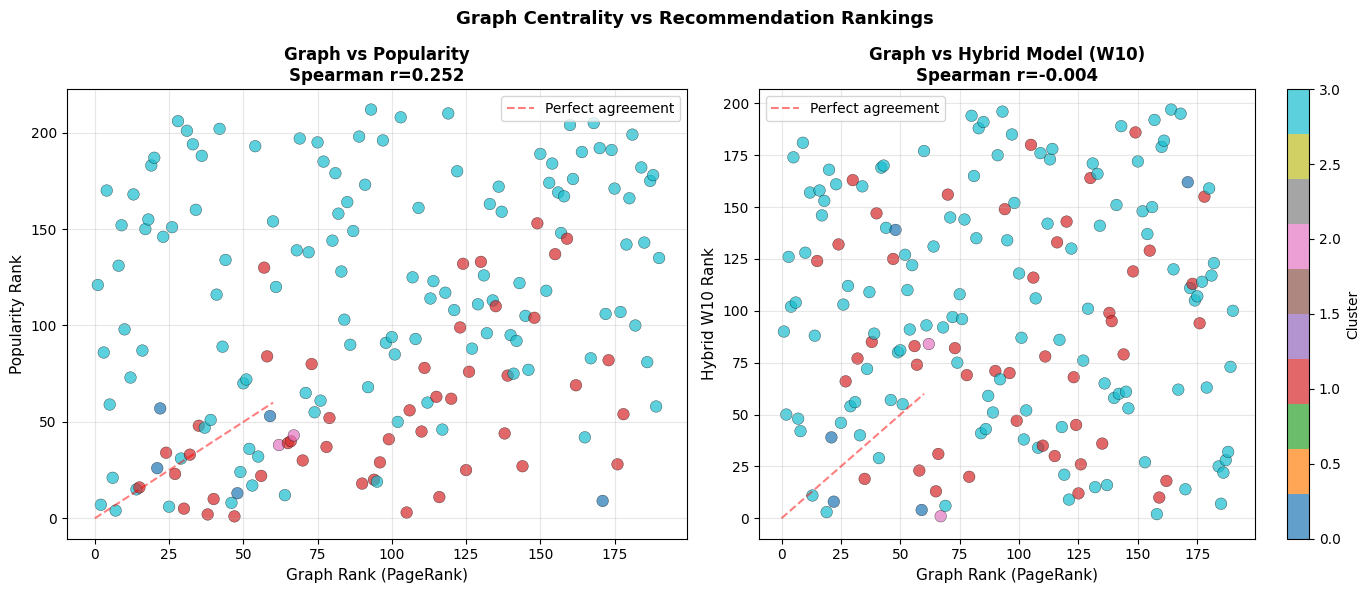

In [ ]:
# ── PLOT 4: Scatter graph rank vs popularity vs hybrid ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(comp_df['graph_rank'], comp_df['popularity_rank'],
                       c=comp_df['cluster'], cmap='tab10',
                       s=70, alpha=0.7, edgecolors='black', linewidths=0.3)
axes[0].plot([0,60],[0,60],'r--',alpha=0.5,label='Perfect agreement')
axes[0].set_xlabel('Graph Rank (PageRank)', fontsize=11)
axes[0].set_ylabel('Popularity Rank', fontsize=11)
axes[0].set_title(f'Graph vs Popularity\nSpearman r={corr_pop:.3f}',
                   fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

sc2 = axes[1].scatter(comp_df['graph_rank'], comp_df['hybrid_rank'],
                       c=comp_df['cluster'], cmap='tab10',
                       s=70, alpha=0.7, edgecolors='black', linewidths=0.3)
axes[1].plot([0,60],[0,60],'r--',alpha=0.5,label='Perfect agreement')
axes[1].set_xlabel('Graph Rank (PageRank)', fontsize=11)
axes[1].set_ylabel('Hybrid W10 Rank', fontsize=11)
axes[1].set_title(f'Graph vs Hybrid Model (W10)\nSpearman r={corr_hyb:.3f}',
                   fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.colorbar(sc2, ax=axes[1], label='Cluster')
plt.suptitle('Graph Centrality vs Recommendation Rankings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The comparison reveals that graph centrality captures information largely independent from both popularity and recommendation rankings.

The weak positive correlation between graph rank and popularity rank (Spearman = 0.252) suggests that structurally central cities tend to be somewhat popular, but popularity alone does not explain their position within the city similarity network.

More importantly, graph rank and hybrid recommendation rank are essentially uncorrelated (Spearman = -0.004). This indicates that the recommendation model prioritizes cities based on user behavior and collaborative filtering signals, whereas graph centrality identifies structurally representative cities based on personality similarity.

Therefore, graph analytics provides complementary information rather than duplicating the recommendation model.

In [ ]:
# ── Hidden gems vs CF favorites ───────────────────────────────────
hidden_gems = comp_df[
    (comp_df['graph_rank'] <= 20) &
    (comp_df['hybrid_rank'] > 40)
].sort_values('graph_rank')

cf_favorites = comp_df[
    (comp_df['hybrid_rank'] <= 20) &
    (comp_df['graph_rank'] > 40)
].sort_values('hybrid_rank')

print('=== HIDDEN GEMS ===')
print('Central in graph but underranked by hybrid — structurally archetypal, low user traffic:')
if len(hidden_gems):
    print(hidden_gems[['city','graph_rank','hybrid_rank','popularity_rank','cluster']].to_string(index=False))
else:
    print('None found at this threshold — try lowering graph_rank cutoff')

print('\n=== CF FAVORITES ===')
print('Ranked high by hybrid but not central in graph — popular with users, not archetypal:')
if len(cf_favorites):
    print(cf_favorites[['city','graph_rank','hybrid_rank','popularity_rank','cluster']].to_string(index=False))
else:
    print('None found at this threshold')

=== HIDDEN GEMS ===
Central in graph but underranked by hybrid — structurally archetypal, low user traffic:
          city  graph_rank  hybrid_rank  popularity_rank  cluster
     levittown           1           90              121        3
       brandon           2           50                7        3
    florissant           3          126               86        3
        smyrna           4          102              170        3
     greenwood           5          174               59        3
       marlton           6          104               21        3
   cherry hill           7           48                4        3
   mooresville           8           42              131        3
        arnold           9          181              152        3
    warminster          10          128               98        3
   springfield          12          157               73        3
          lutz          14           88               15        3
       ardmore          15        

The hidden gems analysis identifies cities that occupy highly central positions in the city personality graph but receive relatively low scores from the hybrid recommendation model.

Examples include Levittown, Florissant, Smyrna, Greenwood, Warminster, and Springfield. These cities function as structural archetypes because they are connected to many similar destinations, yet they attract comparatively little recommendation traffic.

This suggests that the recommendation system may be underexposing commercially representative destinations. Such cities could be valuable candidates for diversification strategies, exploration recommendations, or serendipitous discovery features.

Most hidden gems belong to Cluster 3, reinforcing the observation that this cluster forms the structural backbone of the city personality network.

##Week 11->13

This section examines how a set of cities recommended by the Week 11 hybrid model are positioned within the city similarity graph. Specifically, we analyze their cluster, local graph neighborhoods, centrality scores, and shortest-path distances to the user's historical cities.

looking up the recommended cities for a user in week 11

In [ ]:
target_cities = [
    'downingtown',
    'paoli',
    'berwyn',
    'royersford',
    'maryland heights'
]

centrality_df[
    centrality_df['city'].isin(target_cities)
].sort_values('pagerank', ascending=False)

,city,degree,strength,betweenness,closeness,pagerank,eigenvector,cluster,n_businesses
71,royersford,8,6.647442,0.010863,1.211750,0.005924,0.089665,3,168.0
133,downingtown,4,3.142071,0.000000,1.197525,0.003232,0.016359,3,1.0
136,paoli,2,1.582937,0.003321,1.002136,0.003085,0.000099,3,152.0
166,maryland heights,2,1.505685,0.000000,1.104894,0.001955,0.017007,3,207.0


all where from cluster 3 and 3 out of the 4 recommended cities are direct neighbors

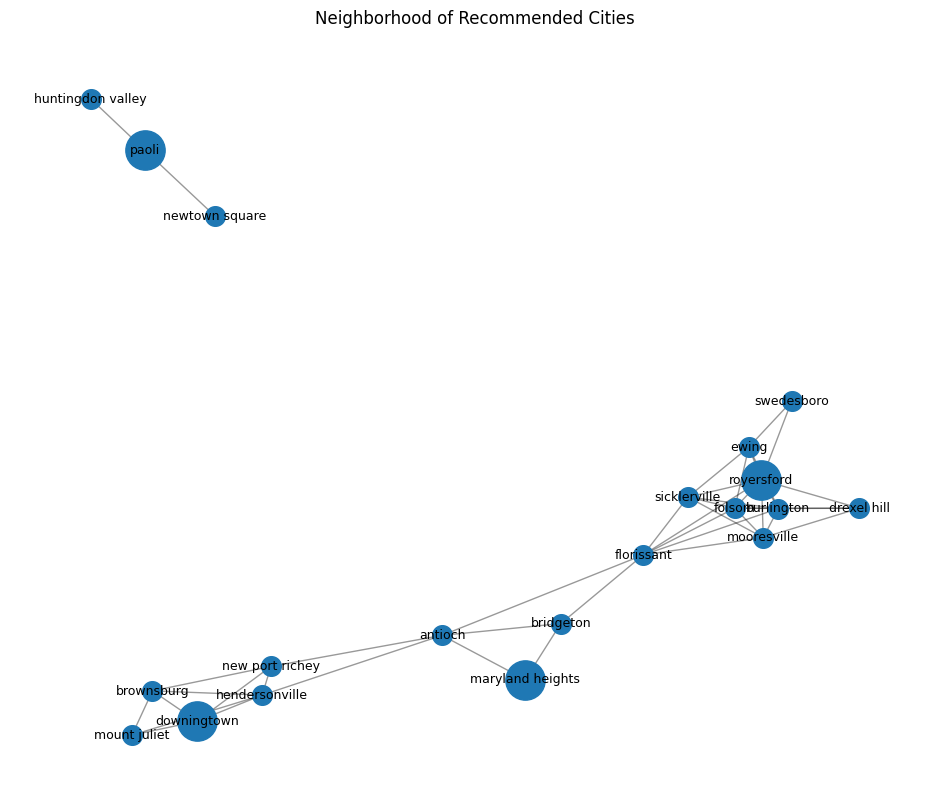

In [ ]:
target_cities = [
    'downingtown',
    'paoli',
    'berwyn',
    'royersford',
    'maryland heights'
]

sub_nodes = set()

for city in target_cities:
    if city in G_main:
        sub_nodes.add(city)
        sub_nodes.update(G_main.neighbors(city))

H = G_main.subgraph(sub_nodes)

plt.figure(figsize=(12,10))

pos_sub = nx.spring_layout(H, seed=42)

nx.draw_networkx_edges(H, pos_sub, alpha=0.4)

nx.draw_networkx_nodes(
    H,
    pos_sub,
    node_size=200
)

nx.draw_networkx_nodes(
    H,
    pos_sub,
    nodelist=[c for c in target_cities if c in H.nodes()],
    node_size=800
)

nx.draw_networkx_labels(
    H,
    pos_sub,
    font_size=9
)

plt.title("Neighborhood of Recommended Cities")
plt.axis("off")
plt.show()

In [ ]:
user_cities = [
    'exton',
    'malvern',
    'phoenixville'
]

recommended = [
    'downingtown',
    'paoli',
    'royersford',
    'maryland heights'
]

print("="*80)
print("USER CITIES")
print("="*80)

for city in user_cities:
    if city in G_main:
        print(
            f"{city:15s}",
            f"cluster={G_main.nodes[city]['cluster']}",
            f"degree={G_main.degree(city)}"
        )
    else:
        print(f"{city:15s} NOT IN GRAPH")


print("\n")
print("="*80)
print("RECOMMENDED CITIES")
print("="*80)

for city in recommended:
    if city in G_main:
        print(
            f"{city:15s}",
            f"cluster={G_main.nodes[city]['cluster']}",
            f"degree={G_main.degree(city)}"
        )
    else:
        print(f"{city:15s} NOT IN GRAPH")

USER CITIES
exton           cluster=3 degree=10
malvern         NOT IN GRAPH
phoenixville    cluster=1 degree=2


RECOMMENDED CITIES
downingtown     cluster=3 degree=4
paoli           cluster=3 degree=2
royersford      cluster=3 degree=8
maryland heights cluster=3 degree=2


The recommended cities are not direct neighbors of the user's historical cities. However, they are reachable through short paths (3–4 hops) within the main connected component and belong to the same dominant cluster, indicating structural similarity in the commercial personality network.

In [ ]:
print("="*80)
print("SHORTEST PATHS")
print("="*80)

for u in user_cities:
    for r in recommended:

        if u not in G_main or r not in G_main:
            continue

        try:
            d = nx.shortest_path_length(G_main, u, r)

            print(
                f"{u:15s} --> {r:15s}  distance = {d}"
            )

        except nx.NetworkXNoPath:

            print(
                f"{u:15s} --> {r:15s}  NO PATH"
            )

SHORTEST PATHS
exton           --> downingtown      distance = 3
exton           --> paoli            distance = 3
exton           --> royersford       distance = 4
exton           --> maryland heights  distance = 4
phoenixville    --> downingtown      distance = 8
phoenixville    --> paoli            distance = 5
phoenixville    --> royersford       distance = 9
phoenixville    --> maryland heights  distance = 8


The shortest-path analysis shows that recommended cities are often several hops away from the user's historical cities rather than direct neighbors. Together with the near-zero Spearman correlation between graph and hybrid rankings, this suggests that the graph captures structural relationships that are not explicitly exploited by the hybrid recommender. Therefore, graph analysis provides complementary information about the destination space.

#INTERPRETATION NOTE

In [ ]:
mean_deg = np.mean(list(degrees.values()))
n_comps  = len(components)
largest  = comp_sizes[0]

print('=' * 70)
print('GRAPH STRUCTURE INTERPRETATION — W13')
print('=' * 70)
print(f"""
GRAPH DEFINITION
Nodes:     {G.number_of_nodes()} cities (filtered 70–1043 businesses)
Edges:     {G.number_of_edges()} pairs with cosine similarity ≥ {THRESHOLD}
Threshold: {THRESHOLD} — selected after evaluating graph density and connectivity
Weights:   cosine similarity in PCA-based city personality space
Direction: undirected — similarity is symmetric

CONNECTED COMPONENTS ({n_comps} total)
Largest component: {largest} cities, representing the main network
of structurally similar cities. Smaller components and isolated
nodes correspond to cities with more distinctive personality profiles
that share few similarities with the rest of the catalog.

DEGREE
High-degree cities are connected to many other cities and therefore
represent common personality patterns within the catalog.
Low-degree cities are more specialized and occupy peripheral positions
in the similarity network.

PAGERANK
PageRank measures structural importance by considering both the number
and quality of connections. Cities with high PageRank are connected
to other influential cities and can be interpreted as representative
examples of major personality regions within the network.

BETWEENNESS
High-betweenness cities act as bridges between different regions of
the graph. These cities connect otherwise weakly connected groups and
may represent transitional or mixed personality profiles.

GRAPH vs POPULARITY (Spearman r={corr_pop:.3f})
The weak positive correlation indicates that structurally important
cities tend to be somewhat more popular, but graph centrality and
popularity capture different notions of importance.

GRAPH vs HYBRID W10 (Spearman r={corr_hyb:.3f})
The near-zero correlation suggests that graph centrality and the
hybrid recommendation model capture largely independent signals.
This result is expected because the graph is constructed from PCA-based
city personality embeddings, whereas the hybrid recommender is primarily
driven by collaborative filtering (85% weight).

DOMAIN MEANING
The graph represents structural similarity relationships between cities
based on their commercial and personality characteristics. Unlike the
hybrid recommender, which emphasizes user behavior and preferences,
the graph focuses on how cities are organized within the catalog itself.
Therefore, graph analytics provides a complementary perspective that
helps identify representative cities, peripheral cities, and structural
patterns that are not directly visible from recommendation rankings alone.
""")


GRAPH STRUCTURE INTERPRETATION — W13

GRAPH DEFINITION
Nodes:     214 cities (filtered 70–1043 businesses)
Edges:     604 pairs with cosine similarity ≥ 0.75
Threshold: 0.75 — selected after evaluating graph density and connectivity
Weights:   cosine similarity in PCA-based city personality space
Direction: undirected — similarity is symmetric

CONNECTED COMPONENTS (23 total)
Largest component: 190 cities, representing the main network
of structurally similar cities. Smaller components and isolated
nodes correspond to cities with more distinctive personality profiles
that share few similarities with the rest of the catalog.

DEGREE
High-degree cities are connected to many other cities and therefore
represent common personality patterns within the catalog.
Low-degree cities are more specialized and occupy peripheral positions
in the similarity network.

PAGERANK
PageRank measures structural importance by considering both the number
and quality of connections. Cities with high PageRank a

In this domain, the graph represents a network of city personalities rather than physical geography. Two cities are connected when their aggregated business ecosystems exhibit similar commercial characteristics.

Central cities represent archetypal destinations whose business composition resembles many other locations. Peripheral cities represent unique or specialized commercial environments.

Consequently, graph centrality can be interpreted as a measure of how representative a city is within the overall destination catalog. While recommendation models identify cities users are likely to visit, graph analytics identifies cities that best characterize the structure of the destination space itself.